<a href="https://colab.research.google.com/github/srinivasveeru/Training/blob/main/LoanDefaultPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

loan(yes/no)                    1.000000
LoanAmount(lakhs)               0.915209
Age                             0.881732
AnnualIncome(lakhs)             0.871254
LoanTerm(years)                 0.866921
EmploymentType_Self-Employed    0.816497
CreditScore(300-900)           -0.887875
Name: loan(yes/no), dtype: float64
Accuracy KNN: 1.0000; ; PrecisionKNN: 1.0000; F1ScoreKNN: 1.0000
Data used for predictions: 
   Age  AnnualIncome(lakhs)  CreditScore(300-900)  LoanAmount(lakhs)  \
8   38                  9.0                   700                  7   
1   45                 12.0                   680                 10   

   LoanTerm(years)  EmploymentType_Self-Employed  
8                8                         False  
1               10                          True  
2
Predictions: ['Will Not default Loan', 'Will loan default']
Accuracy: 1.0000; Precision: 1.0000; F1Score: 1.0000


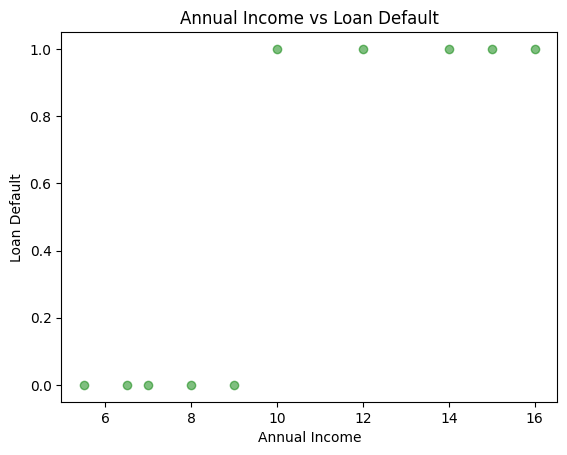

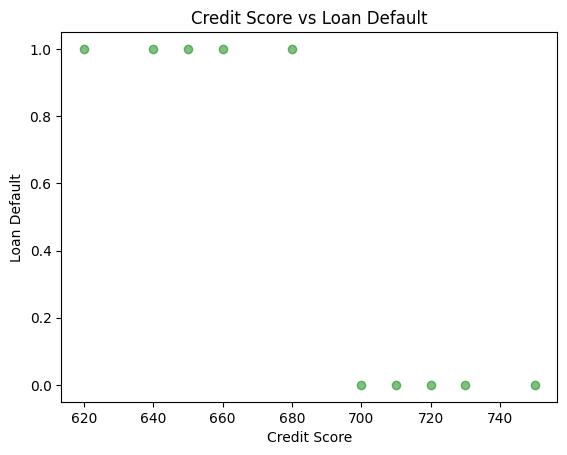

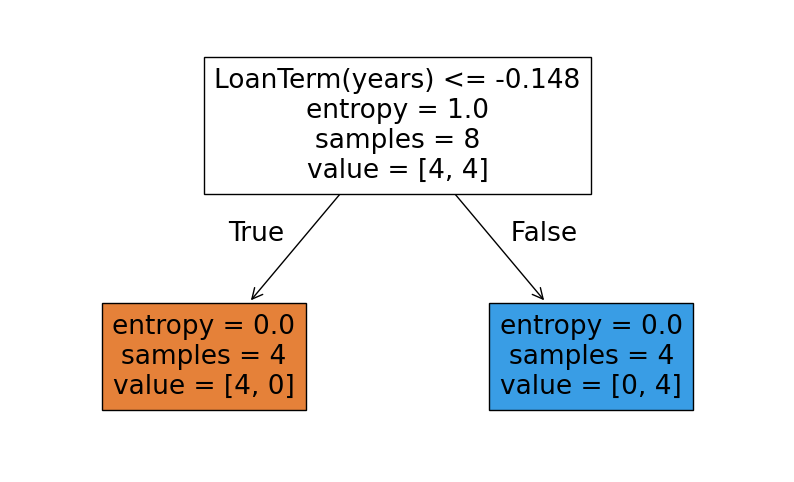

In [ ]:
#A financial institution wants to predict whether a customer will default on a loan before approving it.
#Early identification of risky customers helps reduce financial loss.

#You are working as a Machine Learning Analyst and must build a classification model
#using the K-Nearest Neighbors (KNN) algorithm to predict loan default.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import io
from sklearn.metrics import accuracy_score, r2_score, precision_score, f1_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeClassifier

cv_data = """Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),EmploymentType,loan(yes/no)
28,6.5,720,5,5,Salaried,0
45,12,680,10,10,Self-Employed,1
35,8,750,6,7,Salaried,0
50,15,640,12,15,Self-Employed,1
30,7,710,5,5,Salaried,0
42,10,660,9,10,Salaried,1
26,5.5,730,4,4,Salaried,0
48,14,650,11,12,Self-Employed,1
38,9,700,7,8,Salaried,0
55,16,620,13,15,Self-Employed,1"""

df = pd.read_csv(io.StringIO(cv_data))
#df.info()
#df.head()
#df.describe()

# One-Hot Encoding using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=['EmploymentType'], drop_first=True) # drop_first avoids dummy variable trap
#print(df_encoded)
corr_matrix = df_encoded.corr(numeric_only = True)
print(corr_matrix['loan(yes/no)'].sort_values(ascending=False))
#Based on correlation matrix higher the loan amount leads to loan amount default.
#Lower credit score also increases risk of loan default

plt.scatter(df_encoded['AnnualIncome(lakhs)'], df_encoded['loan(yes/no)'], color = 'green', alpha=0.5)
plt.xlabel('Annual Income')
plt.ylabel('Loan Default')
plt.title('Annual Income vs Loan Default')
plt.show

plt.figure()
plt.scatter(df_encoded['CreditScore(300-900)'], df_encoded['loan(yes/no)'], color = 'green', alpha=0.5)
plt.xlabel('Credit Score')
plt.ylabel('Loan Default')
plt.title('Credit Score vs Loan Default')
plt.show

# Split data
X = df_encoded.drop('loan(yes/no)', axis=1)
y = df_encoded['loan(yes/no)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Implement and train the KNN model
knn = KNeighborsClassifier(n_neighbors=3) # Choose an appropriate K value
knn.fit(X_train_scaled, y_train)

# Make predictions
predictions = knn.predict(X_test_scaled)
accuracyknn = accuracy_score(y_test, predictions)
precisionknn = precision_score(y_test, predictions, average='weighted')
f1knn = f1_score(y_test, predictions, average='weighted')
print(f"Accuracy KNN: {accuracyknn:.4f}; ; PrecisionKNN: {precisionknn:.4f}; F1ScoreKNN: {f1knn:.4f}")
predict = []
print(f'Data used for predictions: \n{X_test}')
print(len(y_test))
for i in range(len(y_test)):
  if(predictions[i] == 0):
    predict.append('Will Not default Loan')
  else:
    predict.append('Will loan default')
print("Predictions:", predict)


# criterion="entropy" uses information gain to decide the splits
classifier = DecisionTreeClassifier(criterion="entropy", max_depth=3)
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}; Precision: {precision:.4f}; F1Score: {f1:.4f}")

plt.figure(figsize=(10,6))
plot_tree(classifier, filled=True, feature_names=X.columns)
plt.show()

